# **Exploring the WHO raw file on tuberculosis burden**

Emma MOUA | 08Sept2026

**Data:** `TB_burden_countries_2025-09-06.csv`, WHO Global Tuberculosis Programme.

**Goal:** Describe the raw file before variable selection and preprocessing:
size, time and geographic coverage, unit of observation, structure of missing values, and
redundancy between candidate variables.

## **Preparation**

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../02_data/raw/TB_burden_countries_2025-09-06.csv")

## **1. Table size**

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5117 entries, 0 to 5116
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   5117 non-null   str    
 1   iso2                      5093 non-null   str    
 2   iso3                      5117 non-null   str    
 3   iso_numeric               5117 non-null   int64  
 4   g_whoregion               5117 non-null   str    
 5   year                      5117 non-null   int64  
 6   e_pop_num                 5117 non-null   int64  
 7   e_inc_100k                5117 non-null   float64
 8   e_inc_100k_lo             5117 non-null   float64
 9   e_inc_100k_hi             5117 non-null   float64
 10  e_inc_num                 5117 non-null   int64  
 11  e_inc_num_lo              5117 non-null   int64  
 12  e_inc_num_hi              5117 non-null   int64  
 13  e_tbhiv_prct              4429 non-null   float64
 14  e_tbhiv_prct_lo    

## **2. Time coverage**

In [3]:
int(df["year"].min()), int(df["year"].max())

(2000, 2023)

24 years covered

## **3. Countries and WHO regions**

In [4]:
df["country"].nunique(), df["g_whoregion"].nunique()

(215, 6)

In [5]:
# Aggregate rows such as "Global" or a WHO region would carry no region code.
int(df["g_whoregion"].isna().sum()), df["country"].str.contains(
    "global|world|total|region", case=False
).sum()

(0, np.int64(0))

No row is missing a region code, and no country name matches an aggregate keyword: the file has only countries and territories, so no row must be filtered out at this stage.

215 countries and 6 regions

## **4. Panel completeness**

A perfectly balanced panel would have one row per country and per year. The number of rows is compared with this product, then the number of rows per year is checked.

In [6]:
df["country"].nunique() * df["year"].nunique(), len(df)

(5160, 5117)

**43 missing rows --> the number of countries per year is not the same each year**

In [7]:
rows_per_year = df.groupby("year").size()
int(rows_per_year.min()), int(rows_per_year.max())

(209, 215)

Countries whose series is shorter than the full period are identified, because a trajectory-based analysis should decide what to do with them.

In [8]:
years_per_country = df.groupby("country")["year"].nunique()
years_per_country[years_per_country < df["year"].nunique()].sort_values()

country
South Sudan                  13
Curaçao                      14
Sint Maarten (Dutch part)    14
Montenegro                   19
Serbia                       19
Timor-Leste                  22
Name: year, dtype: int64

Six territories explain the 43 missing rows. Each one seems to match a change in political status during the period. So the panel is not unbalanced because of a missing measure, but because the countries themselves did not exist for the whole period.

## **5. Observation unit**

Each row is meant to match one country for a given year.

In [9]:
int(df.duplicated(["country", "year"]).sum())

0

The absence of duplicated (country, year) pairs confirms this. The observations are therefore not independent: each country gives several rows.

## **6. What the columns are**

In [10]:
dictionary = pd.read_csv("../02_data/raw/TB_data_dictionary_2025-09-06.csv")

definitions = pd.DataFrame({"variable_name": df.columns}).merge(
    dictionary[["variable_name", "definition"]].drop_duplicates("variable_name"),
    on="variable_name", how="left",
)
definitions.definition.isna().sum(), len(definitions)

(np.int64(1), 50)

In [11]:
pd.set_option("display.max_rows", 50, "display.max_colwidth", 90)
definitions

,variable_name,definition
0,country,Country or territory name
1,iso2,ISO 2-character country/territory code
2,iso3,ISO 3-character country/territory code
3,iso_numeric,ISO numeric country/territory code
4,g_whoregion,WHO region
5,year,NaN
6,e_pop_num,Estimated total population number
7,e_inc_100k,Estimated incidence (all forms) per 100 000 population
8,e_inc_100k_lo,"Estimated incidence (all forms) per 100 000 population, low bound"
9,e_inc_100k_hi,"Estimated incidence (all forms) per 100 000 population, high bound"


## **7. Candidate variables**

The ten distinct measures from the file, along with the population size and the WHO region. The uncertainty bounds
(`*_lo`, `*_hi`), the count duplicates of the rates (`*_num`), and the identifiers can be excluded at this stage.

In [12]:
bounds = [c for c in df.columns if c.endswith(("_lo", "_hi"))]
ids = ["country", "iso2", "iso3", "iso_numeric", "year", "g_whoregion"]
counts = [c for c in df.columns if c.endswith("_num")]
measures = [c for c in df.columns if c not in bounds + ids + counts]

{"bounds": len(bounds), "identifiers": len(ids), "counts": len(counts), "measures": len(measures)}


{'bounds': 28, 'identifiers': 6, 'counts': 6, 'measures': 10}

In [13]:
# Population size and WHO region are added back from their groups.
candidates = measures + ["e_pop_num", "g_whoregion"]

len(candidates), candidates

(12,
 ['e_inc_100k',
  'e_tbhiv_prct',
  'e_inc_tbhiv_100k',
  'e_mort_exc_tbhiv_100k',
  'e_mort_tbhiv_100k',
  'e_mort_100k',
  'cfr',
  'cfr_pct',
  'c_newinc_100k',
  'c_cdr',
  'e_pop_num',
  'g_whoregion'])

## **8. Missing values per candidate variable**

Share of missing values, in percentage, on the whole file.

In [14]:
missing = (df[candidates].isna().mean() * 100).round(1)
missing.sort_values(ascending=False)

e_tbhiv_prct             13.4
e_inc_tbhiv_100k         13.4
c_cdr                     5.7
c_newinc_100k             3.6
cfr                       2.5
cfr_pct                   2.5
e_mort_exc_tbhiv_100k     0.5
e_mort_tbhiv_100k         0.5
e_mort_100k               0.5
e_inc_100k                0.0
e_pop_num                 0.0
g_whoregion               0.0
dtype: float64

Requiring rows with no missing value has a cost in countries. It is measured
on the most recent year, before any imputation choice is made.

In [15]:
year_recent = df[df["year"] == df["year"].max()]
without_hiv = [c for c in candidates if "tbhiv" not in c]

print("countries in the most recent year:", year_recent["country"].nunique())
print("complete on all candidates:", year_recent[candidates].dropna().shape[0])
print("complete once the two HIV variables are set aside:",
      year_recent[without_hiv].dropna().shape[0])

countries in the most recent year: 215
complete on all candidates: 195
complete once the two HIV variables are set aside: 204


Nine countries are lost because of the two variables linked to HIV alone. Decide if the 2 variables are worth this loss.

## **9. Missing values by region**

Whether the missing values are random or not matters for imputation. The variable with the highest overall rate,
`e_tbhiv_prct`, is broken down by WHO region.

In [16]:
by_region = df.groupby("g_whoregion")["e_tbhiv_prct"].apply(lambda x: x.isna().mean())
(by_region * 100).round(1)

g_whoregion
AFR     0.6
AMR    21.3
EMR     1.5
EUR     7.1
SEA    10.1
WPR    37.4
Name: e_tbhiv_prct, dtype: float64

The distribution of missing values shows a strong geographic disparity: almost zero in Africa (0.6%) versus 37.4% in the Western Pacific (WPR) and 21.3% in the Americas (AMR). These gaps are concentrated in small island territories and some countries with low HIV prevalence.

This finding rules out a random absence (*MCAR*) --> simple global imputation should be avoided: the replacement of values must be done at the national level (temporal interpolation) or regional level to keep the local epidemic dynamics.

In [17]:
periods = pd.cut(df["year"], [1999, 2005, 2011, 2017, 2023],
                 labels=["2000-05", "2006-11", "2012-17", "2018-23"])
(df.groupby(periods, observed=True)["e_tbhiv_prct"]
   .apply(lambda x: 100 * x.isna().mean()).round(1))

year
2000-05    19.3
2006-11    12.5
2012-17    12.5
2018-23     9.6
Name: e_tbhiv_prct, dtype: float64

The proportion of missing values for the variable `e_tbhiv_prct` is broken down by period, to tell apart a temporary gap in reporting from a structural absence.

The rate of missing data drops in a steady way, going from 19.3% over 2000-2005 to 9.6% over 2018-2023. This improvement may come from the step-by-step strengthening of epidemiological surveillance systems and WHO recommendations over the last two decades.

But limiting the analysis to recent years does not fully solve the problem, since close to 10% of missing data remains over 2018-2023, concentrated in about thirty territories. Also, such a filter would cut the historical depth from 24 to 6 years, which would limit the analysis of long epidemic trajectories. It is thus better to keep the whole period, while combining a temporal interpolation by country with a targeted treatment of undocumented territories.

## **10. Redundancy between candidate variables**

The variables that are thought to be duplicates are tested on the data. A correlation of 1 shows a strict redundancy.

In [18]:
df[["cfr", "cfr_pct"]].corr()

,cfr,cfr_pct
cfr,1.0,1.0
cfr_pct,1.0,1.0


The `cfr` is compared to the mortality/incidence ratio. We often assume that it is equal to this ratio.

In [19]:
ratio = df["e_mort_100k"] / df["e_inc_100k"]
correlation = df["cfr"].corr(ratio)

print("correlation with the mortality-to-incidence ratio:", round(correlation, 3))
print("share of the variance of cfr it leaves unexplained (%):",
      round((1 - correlation ** 2) * 100, 1))

correlation with the mortality-to-incidence ratio: 0.924
share of the variance of cfr it leaves unexplained (%): 14.6


Even if the mortality/incidence ratio gives an idea of lethality, it is not the same as the cfr. The correlation is strong (r = 0.924), but 14.6% of the variance is not explained --> This is normal because a patient does not always die the same year they fall sick, and the WHO also adjusts its estimates based on access to treatment.

The `_num` columns are meant to be the `_100k` equivalent, rescaled by population --> not kept as candidates.

In [20]:
rescaled = df["e_inc_100k"] * df["e_pop_num"] / 1e5
df["e_inc_num"].corr(rescaled)

np.float64(0.9999983653651411)

The correlation is 0.999998, so `e_inc_num` carries no information beyond incidence and population, both already present. The gap from exactly 1 is more likely due to rounding of the published values, not a different quantity --> keep the normalized value instead

## **11. Figure: missing values by candidate variable**

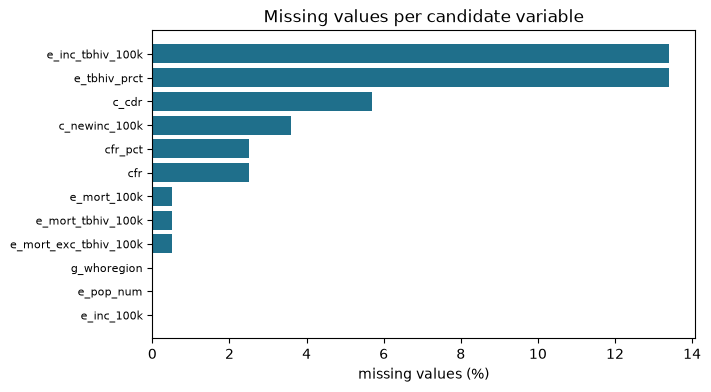

In [21]:
ordered = missing.sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(ordered.index, ordered.values, color="#1f6f8b")
ax.set_xlabel("missing values (%)")
ax.set_title("Missing values per candidate variable")
ax.tick_params(axis="y", labelsize=8)

fig.savefig("../05_figures/01_exploration/missing_values.png", dpi=200, bbox_inches="tight")

## **12. Distributions and extreme values**
The candidate variables are summed up for the most recent year, so that each country
gives one single value.

In [22]:
recent = df[df["year"] == 2023]
numeric_candidates = df[candidates].select_dtypes("number").columns.tolist()

recent[numeric_candidates].describe().round(1)

,e_inc_100k,e_tbhiv_prct,e_inc_tbhiv_100k,e_mort_exc_tbhiv_100k,e_mort_tbhiv_100k,e_mort_100k,cfr,cfr_pct,c_newinc_100k,c_cdr,e_pop_num
count,215.0,197.0,197.0,214.0,214.0,214.0,212.0,212.0,206.0,205.0,2.150000e+02
mean,101.0,8.6,15.0,10.5,4.3,14.8,0.1,14.2,70.3,77.1,3.750403e+07
std,144.1,12.0,42.4,17.4,14.8,28.4,0.1,13.9,98.5,21.0,1.434022e+08
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.816000e+03
25%,8.4,1.1,0.2,0.5,0.0,0.7,0.1,7.0,7.6,65.0,8.383715e+05
50%,42.0,4.1,1.3,2.5,0.2,3.2,0.1,10.0,32.5,81.0,6.823619e+06
75%,130.5,11.0,6.8,12.0,1.5,17.8,0.2,17.0,88.8,87.0,2.643466e+07
max,692.0,63.0,362.0,91.0,161.0,229.0,1.0,100.0,554.0,190.0,1.438070e+09


In [23]:
recent[numeric_candidates].skew().round(2).sort_values(ascending=False)

e_pop_num                8.75
e_mort_tbhiv_100k        6.84
e_inc_tbhiv_100k         4.79
e_mort_100k              3.77
cfr                      3.52
cfr_pct                  3.52
e_tbhiv_prct             2.51
e_mort_exc_tbhiv_100k    2.49
c_newinc_100k            2.31
e_inc_100k               2.04
c_cdr                   -0.01
dtype: float64

In [24]:
# The 1.5 IQR fence, on e_inc_100k.
q1, q3 = recent["e_inc_100k"].quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)

print("upper fence:", round(upper_fence, 1), "per 100 000")
print("countries beyond it:", int((recent["e_inc_100k"] > upper_fence).sum()))

upper fence: 313.7 per 100 000
countries beyond it: 21


All variables except `c_cdr` are right-skewed, strongly so for population (8.75) and for HIV-related mortality (6.84).
Tuberculosis incidence goes from a median of 42 to a maximum of 692 cases per 100,000; 21 countries fall beyond the 1.5 IQR limit.

The fact that these are errors is tested, not assumed. A data entry error would show up as an isolated spike in a country's series and would contradict the other columns of the same row; both are checked for the three highest values.

In [25]:
extremes = recent.nlargest(3, "e_inc_100k")["country"].tolist()
(df[df["country"].isin(extremes)]
   .pivot_table(index="year", columns="country", values="e_inc_100k")
   .loc[::4])

country,Lesotho,Marshall Islands,Philippines
year,,,
2000,827.0,84.0,590.0
2004,1150.0,282.0,549.0
2008,1240.0,300.0,524.0
2012,1040.0,352.0,539.0
2016,721.0,469.0,554.0
2020,609.0,430.0,535.0


In [26]:
recent.loc[recent["country"].isin(extremes),
           ["country", "e_inc_100k", "e_inc_100k_lo", "e_inc_100k_hi",
            "c_newinc_100k", "e_inc_num", "e_pop_num"]]

,country,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,c_newinc_100k,e_inc_num,e_pop_num
2605,Lesotho,664.0,335.0,985.0,281.0,15000,2311476
2869,Marshall Islands,692.0,530.0,875.0,554.0,270,38833
3656,Philippines,643.0,296.0,1120.0,501.0,739000,114891201


In [27]:
# A high rate and a high case count do not give the same ranking.
ranked = recent.assign(
    rank_by_rate=recent["e_inc_100k"].rank(ascending=False, method="min"),
    rank_by_cases=recent["e_inc_num"].rank(ascending=False, method="min"))

print(ranked.nlargest(4, "e_inc_num")[["country", "e_inc_num"]].to_string(index=False))

ranked.loc[ranked["country"].isin(extremes),
           ["country", "e_inc_100k", "rank_by_rate", "e_inc_num", "rank_by_cases"]]

    country  e_inc_num
      India    2800000
  Indonesia    1090000
      China     741000
Philippines     739000


,country,e_inc_100k,rank_by_rate,e_inc_num,rank_by_cases
2605,Lesotho,664.0,2.0,15000,57.0
2869,Marshall Islands,692.0,1.0,270,151.0
3656,Philippines,643.0,3.0,739000,4.0


The three highest incidence rates in 2023 are the Marshall Islands (692 per 100,000), Lesotho (664) and the Philippines (643). These are not outliers, because their history is consistent over the full period: Lesotho reached a peak at 1,240 in 2008 before going back down, the Marshall Islands has been rising since 84 in 2000, and the Philippines stays stable between 520 and 643. The notified incidence is also very high there and the uncertainty intervals stay plausible, which justifies keeping this data.

These numbers also remind us that a ranking by incidence rate is different from a ranking by absolute volume. The Marshall Islands is first by incidence rate but 151st in real case count (270 cases), while Lesotho has 15,000 cases and the Philippines has 739,000. In fact, the WHO list of 30 priority countries combines the 20 biggest hotspots by absolute volume and 10 countries with a high rate that go over 10,000 cases per year. The Marshall Islands cannot reach this threshold, unlike Lesotho and the Philippines.
Last, the strong asymmetry (skewness) is not an anomaly but a natural feature of these variables.

**--> Remember to do a log transformation before using distance-based methods (like PCA or clustering), so that a few extreme values do not crush the analysis.**

/var/folders/wt/l0lngsps0plgtx820wcjlbsw0000gn/T/ipykernel_85462/3812971900.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([recent[c].dropna() for c in rates], vert=False,


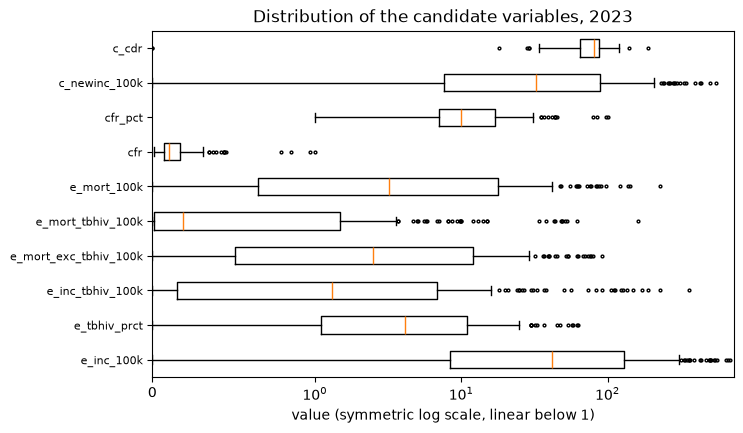

In [28]:
rates = [c for c in numeric_candidates if c != "e_pop_num"]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.boxplot([recent[c].dropna() for c in rates], vert=False,
           flierprops={"marker": ".", "markersize": 4})
ax.set_yticks(range(1, len(rates) + 1), rates, fontsize=8)
ax.set_xscale("symlog", linthresh=1)
ax.set_xlim(left=0)
ax.set_xlabel("value (symmetric log scale, linear below 1)")
ax.set_title("Distribution of the candidate variables, 2023")
ax.tick_params(axis="y", labelsize=8)

fig.savefig("../05_figures/01_exploration/distributions.png", dpi=200, bbox_inches="tight")

## **13. Correlation structure**

The pairwise correlations of the numeric candidates give a first view of the structure
that the modeling step will need to handle. `cfr_pct` is excluded, since it is already known to
duplicate `cfr`.

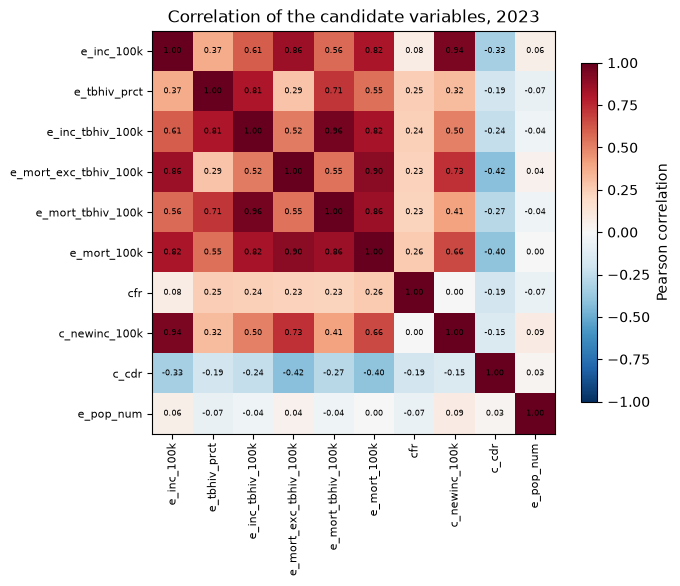

In [29]:
to_correlate = [c for c in numeric_candidates if c != "cfr_pct"]
correlations = recent[to_correlate].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
image = ax.imshow(correlations, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(to_correlate)), to_correlate, rotation=90, fontsize=8)
ax.set_yticks(range(len(to_correlate)), to_correlate, fontsize=8)
for row in range(len(to_correlate)):
    for col in range(len(to_correlate)):
        ax.text(col, row, f"{correlations.iloc[row, col]:.2f}",
                ha="center", va="center", fontsize=6)
fig.colorbar(image, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Correlation of the candidate variables, 2023")

fig.savefig("../05_figures/01_exploration/correlations.png", dpi=200, bbox_inches="tight")

In [30]:
# The figure rounds to two decimals; the strongest pairs are listed exactly.
pairs = correlations.stack()
pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]

pairs.sort_values(ascending=False).head(5).round(3)

e_inc_tbhiv_100k  e_mort_tbhiv_100k        0.956
c_newinc_100k     e_inc_100k               0.938
e_mort_100k       e_mort_exc_tbhiv_100k    0.899
e_inc_100k        e_mort_exc_tbhiv_100k    0.858
e_mort_100k       e_mort_tbhiv_100k        0.858
dtype: float64

Three pairs stand out: estimated incidence and notified incidence (0.938), the two
variables linked to HIV (0.956), and total mortality with its HIV-negative component (0.899). None
reaches the strict redundancy of `cfr_pct`, but the block structure they form is what a
principal component analysis would sum up, and this is a reason to expect
unstable coefficients for a linear model fitted on the full set of these variables.

## **14. Trend in incidence by WHO region**

The median of incidence by region over the period places the data in time. The median
is preferred over the mean given the skewness measured in section 12.

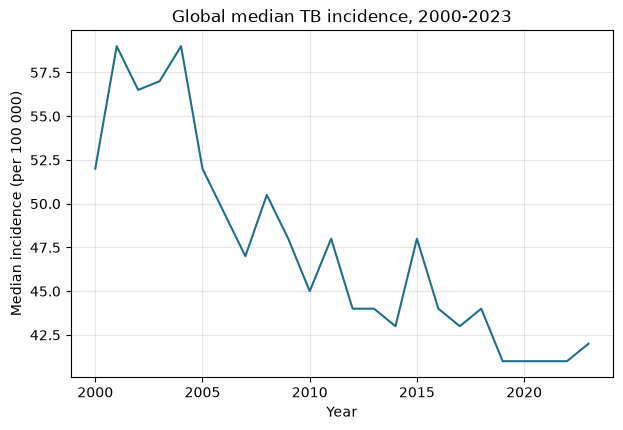

In [31]:
global_trend = df.groupby("year")["e_inc_100k"].median()

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    global_trend.index,
    global_trend.values,
    marker="",
    color="#1f6f8b",
)

ax.set_xlabel("Year")
ax.set_ylabel("Median incidence (per 100 000)")
ax.set_title("Global median TB incidence, 2000-2023")
ax.grid(True, alpha=0.3)

fig.savefig(
    "../05_figures/01_exploration/incidence_trend_global.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

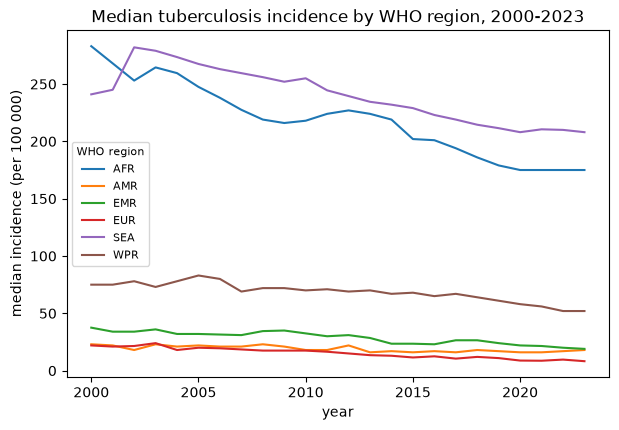

In [32]:
trend = df.groupby(["year", "g_whoregion"])["e_inc_100k"].median().unstack()

fig, ax = plt.subplots(figsize=(7, 4.5))
for region in trend.columns:
    ax.plot(trend.index, trend[region], marker="", label=region)
ax.set_xlabel("year")
ax.set_ylabel("median incidence (per 100 000)")
ax.set_title("Median tuberculosis incidence by WHO region, 2000-2023")
ax.legend(title="WHO region", fontsize=8, title_fontsize=8)

fig.savefig("../05_figures/01_exploration/incidence_trend.png", dpi=200, bbox_inches="tight")

In [33]:
change = pd.DataFrame({"median_2000": trend.loc[2000].round(1),
                       "median_2023": trend.loc[2023].round(1)})
change["change_pct"] = ((change["median_2023"] / change["median_2000"] - 1) * 100).round(1)

change.sort_values("median_2023", ascending=False)

,median_2000,median_2023,change_pct
g_whoregion,,,
SEA,241.0,208.0,-13.7
AFR,283.0,175.0,-38.2
WPR,75.0,52.0,-30.7
EMR,37.5,19.0,-49.3
AMR,23.0,18.0,-21.7
EUR,22.0,8.2,-62.7


All six regions decline over the period, but at very different speeds: -62.7% in the European Region and -49.3% in the Eastern Mediterranean Region, against -13.7% in the South-East Asia Region and -21.7% in the Region of the Americas. The African and South-East Asia Regions stay one order of magnitude above the European Region in 2023 (175 and 208 versus 8.2 per 100 000).

**For the biological question**: The decrease is general --> the truly informative quantity is its speed, not its existence: a target set on the rate of decrease separates the regions, while a target set on the decline alone would not do so.

## Findings

1. **Size and observation unit:** 5,117 rows and 50 columns; one row is one country for one year, with no duplicate pair. Observations within the same country are therefore correlated.
2. **Coverage:** 2000 to 2023 (24 years), 215 countries and territories, 6 WHO regions. No aggregate row: each row has a region code and no country name matches an aggregate keyword.
3. **Unbalanced panel:** A balanced panel would have 5,160 rows; 5,117 are observed. The 43 missing rows are concentrated in six territories (South Sudan, Curaçao, Sint Maarten, Montenegro, Serbia, Timor-Leste), whose series span 13 to 22 years instead of 24. Interpretation: change of political status. Restricting the analysis to countries with a complete series is a major choice and would remove these six territories.
4. **Missing values:** The highest rates are for the two HIV-related variables (13.4% over the whole period, 8.4% in 2023), then `c_cdr` (5.7%), `c_newinc_100k` (3.6%) and `cfr` (2.5%); incidence, population and region are complete. No variable reaches the level where imputation would supply more values than the file already holds, so no variable is dropped for missing values alone. Requiring the 12 candidates to be present in 2023 keeps 195 of the 215 countries, versus 204 without the two HIV-related variables.
5. **The absence of values is not random:** For `e_tbhiv_prct`, the rate ranges from 0.6% in the African Region to 37.4% in the Western Pacific Region, and falls over time, from 19.3% in 2000-05 to 9.6% in 2018-23. Imputing with the mean across countries would introduce a regional bias and is ruled out.
6. **Redundancy:** The variable `cfr_pct` is a simple duplicate of cfr expressed as a percentage (`cfr_pct` = 100 * cfr, correlation of 1.0): so we keep only cfr. On the other hand, cfr is not a simple direct calculation of mortality divided by incidence (r = 0.924, 14.6% of variance unexplained), which justifies keeping it as its own variable. Lastly, since the raw case count (`e_inc_num`) is the deterministic product of the rate and the population (r > 0.9999), all absolute-value variables (`_num`) are excluded to avoid duplicates with the rates per 100,000.
7. **Distributions and extreme values:** All candidates except `c_cdr` show a right skew (right-skewed), reaching up to 8.75 for population. Incidence in 2023 ranges from a median of 42 to 692 per 100,000, with 21 countries beyond the 1.5 IQR limit. These extreme values are not errors: each of the three highest series stays stable at this level over the whole period, its reported incidence is also high, and its published uncertainty interval brackets the estimate. They are kept as valid observations, but a logarithmic transform is needed before any distance-based method. The rate and the absolute burden rank differently: the highest rate in 2023 corresponds to 270 estimated cases, so the two must not be used interchangeably.
8. **Correlation structure:** Several pairs of variables are highly correlated: estimated incidence and reported incidence (r = 0.938), the HIV-related variables (r = 0.956), and overall mortality with its non-HIV component (r = 0.899). Even if this information is not strictly identical, such correlation risks destabilizing linear regressions (multicollinearity). This justifies either summarizing these variables (by PCA) or selecting only one per thematic group.
9. **Time structure:** Median incidence declines in all six regions between 2000 and 2023, from -62.7% (European Region) to -13.7% (South-East Asia Region), while absolute levels differ by an order of magnitude. A target based on the speed of decline is therefore more informative than a target based only on whether decline exists.

## Preprocessing decisions


### Decisions to validate

* **D1. Column selection:** 
  * We remove the uncertainty bounds (`_lo`, `_hi`), because they show the margin of error of the calculation, not the true state of the country.
  * We drop the variables in absolute count (`_num`), since they duplicate the rates per 100,000 multiplied by the population (already present in the table).
  * We remove `cfr_pct`, a simple copy of `cfr` multiplied by 100.
  * The identifiers (`iso2`, `iso3`, `iso_numeric`) are removed, and `country` is used only as an identifier to group the data, not as a predictive variable.

* **D2. Choice of the analysis scale:** We work on the normalized rates (`_100k`) to compare countries fairly. The population size (`e_pop_num`) stays as an explanatory variable, but not as a direct sign of how strong the epidemic is.

* **D3. Handling of extreme values:** No clipping and no removal of countries beyond the classic whisker threshold (1.5 IQR). These very high values are checked against the reported cases and the history: they are real signals, not typos.

* **D4. Log transformation:** We apply `log1p` to the rates before computing distances or standardizing (PCA, $K$-means, hierarchical clustering, KNN). This stops the very high values from dominating the variance. On the other hand, no log transform for tree-based models, which are not sensitive to this problem.

* **D5. Prevention of data leakage:** All centering-scaling and transformation steps are fit only on the training set, then applied as is on the validation and test sets.

* **D6. Train/test split strategy:** We do not allow a purely random split of rows, because two consecutive years of the same country would influence each other. We split by country (`GroupKFold`) or by time period (training on the past, testing on the recent years).

* **D7. Imputation rule:** Never a global mean or median computed over all countries together, because missing data depends too much on the geographic area. We impute only within each country (interpolation over time), and we add a binary imputation flag (column) to mark the replaced values.

* **D8. Keeping all territories:** We keep the six territories that have less than 24 years of follow-up (such as South Sudan or Montenegro). Removing them would change our field of study in an arbitrary way.

* **D9. Encoding of the region:** The column `g_whoregion` is turned into binary indicators (*one-hot encoding*), without assuming any order between the regions.

---

### Open questions to settle

* **A1. Choice on the HIV variables:** Keeping them means losing a few countries with no data (195 kept out of 215 in 2023), while removing them lets us keep 204 countries. This trade-off depends on how much weight we give to HIV in our problem.

* **A2. Handling of strongly correlated variables:** Should we summarize the redundant blocks of indicators with a PCA (at the risk of losing readability), or simply pick one representative variable per theme (simpler to interpret)?

* **A3. Exact wording of the target:** What do we want to predict exactly: the future incidence rate (continuous regression), the speed at which the epidemic goes down, or groups of typical trajectories (unsupervised clustering)?